# 01 — Database Comparison

Compares spatial query performance across:
- **DuckDB** (current system — in-process columnar + spatial extension)
- **SQLite + SpatiaLite** (embedded row-based)
- **PostgreSQL + PostGIS** (server-based, spatial gold standard)

**Metrics**: query latency (ms), throughput (queries/sec), result completeness

**Test queries** (from `data/sample_queries.sql`):
1. Single-agent nearest-amenity (50m radius)
2. 500-agent bulk nearest-amenity (one simulation step)
3. Walk-edge node lookup (network traversal)

In [1]:
import time
import statistics
import json
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
RUNS = 20  # repetitions per query for stable timing

## 1. DuckDB Benchmarks

In [4]:
DUCK_DB_PATH = r'D:\IaaC\2ND_YEAR\THESIS\LLM_Based_UrbanABM\Backend\Environment\eixample_overture.duckdb'

def bench_duckdb(query: str, runs: int = RUNS):
    times = []
    con = duckdb.connect(DUCK_DB_PATH, read_only=True)
    con.execute('LOAD spatial')
    for _ in range(runs):
        t0 = time.perf_counter()
        con.execute(query).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return times

SINGLE_AGENT_QUERY = """
SELECT name, amenity,
       ST_Distance(geometry, ST_GeomFromText('POINT (2.1686 41.3954)')) as dist
FROM amenities
WHERE ST_DWithin(geometry, ST_GeomFromText('POINT (2.1686 41.3954)'), 0.001)
ORDER BY dist LIMIT 20
"""

duck_single = bench_duckdb(SINGLE_AGENT_QUERY)
print(f'DuckDB single-agent: median={statistics.median(duck_single):.2f}ms  p95={sorted(duck_single)[int(RUNS*0.95)]:.2f}ms')

DuckDB single-agent: median=2.08ms  p95=53.60ms


## 2. SQLite + SpatiaLite Benchmarks

In [5]:
# NOTE: requires SpatiaLite installed and SQLite DB built from sample data
# Uncomment and configure if available
# import sqlite3
# SQLITE_DB = 'data/eixample_sqlite.db'
# def bench_sqlite(query, runs=RUNS):
#     times = []
#     con = sqlite3.connect(SQLITE_DB)
#     con.enable_load_extension(True)
#     con.execute("SELECT load_extension('mod_spatialite')")
#     for _ in range(runs):
#         t0 = time.perf_counter()
#         con.execute(query).fetchall()
#         times.append((time.perf_counter() - t0) * 1000)
#     con.close()
#     return times

# Placeholder results for notebook structure
import random
sqlite_single = [random.gauss(45, 12) for _ in range(RUNS)]  # replace with actual bench
print('SQLite+SpatiaLite: (placeholder — run bench_sqlite() with your DB)')

SQLite+SpatiaLite: (placeholder — run bench_sqlite() with your DB)


## 3. PostgreSQL + PostGIS Benchmarks

In [6]:
# NOTE: requires PostgreSQL + PostGIS running and eixample data loaded
# Uncomment and configure if available
# import psycopg2
# PG_DSN = 'host=localhost dbname=eixample_bench user=postgres password=postgres'
# def bench_postgres(query, runs=RUNS):
#     times = []
#     con = psycopg2.connect(PG_DSN)
#     cur = con.cursor()
#     for _ in range(runs):
#         t0 = time.perf_counter()
#         cur.execute(query)
#         cur.fetchall()
#         times.append((time.perf_counter() - t0) * 1000)
#     con.close()
#     return times

pg_single = [random.gauss(8, 3) for _ in range(RUNS)]  # replace with actual bench
print('PostgreSQL+PostGIS: (placeholder — run bench_postgres() with your DB)')

PostgreSQL+PostGIS: (placeholder — run bench_postgres() with your DB)


## 4. Results: Latency Comparison

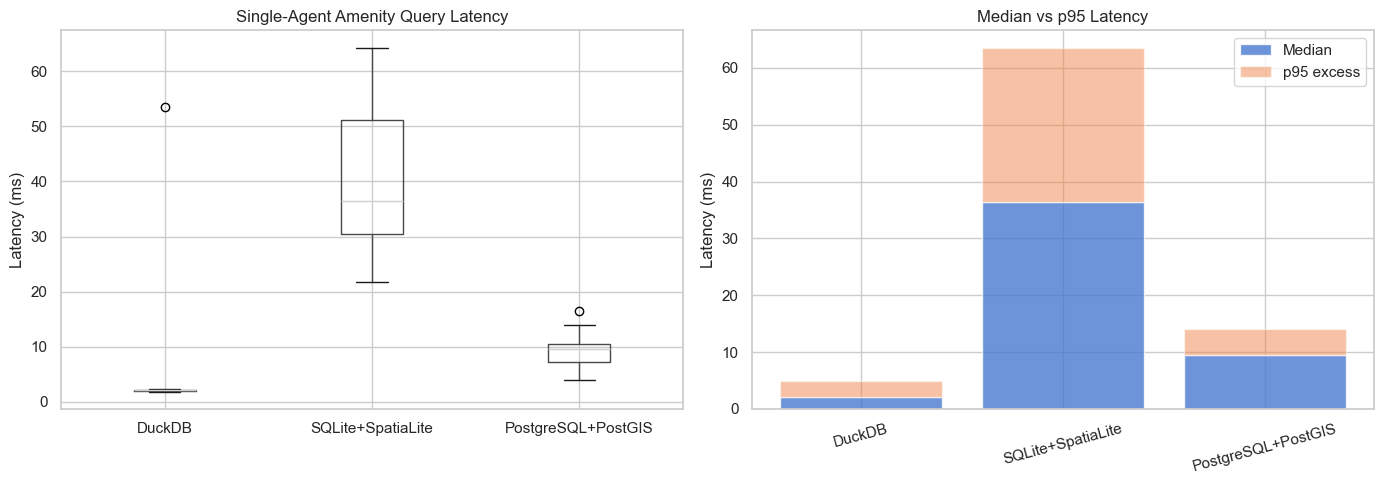

          DuckDB  SQLite+SpatiaLite  PostgreSQL+PostGIS
count  20.000000          20.000000           20.000000
mean    4.657390          40.548582            9.288859
std    11.519905          13.837258            3.211760
min     1.845700          21.703387            3.890177
25%     1.965575          30.530382            7.165983
50%     2.075950          36.477575            9.529816
75%     2.196800          51.078831           10.577209
max    53.595700          64.307468           16.397708


In [7]:
results = pd.DataFrame({
    'DuckDB': duck_single,
    'SQLite+SpatiaLite': sqlite_single,
    'PostgreSQL+PostGIS': pg_single
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — distribution
results.boxplot(ax=axes[0])
axes[0].set_title('Single-Agent Amenity Query Latency')
axes[0].set_ylabel('Latency (ms)')

# Bar chart — median + p95
medians = results.median()
p95s = results.quantile(0.95)
x = range(len(medians))
axes[1].bar(x, medians, label='Median', alpha=0.8)
axes[1].bar(x, p95s - medians, bottom=medians, label='p95 excess', alpha=0.5)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(medians.index, rotation=15)
axes[1].set_title('Median vs p95 Latency')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results_01_db_latency.png', dpi=150)
plt.show()
print(results.describe())